# Notebook 01 — Data Preprocessing & Feature Engineering
## Corruption Indication Detection in Village Fund Activities — Jambi Province 2023–2025

**Research**: Comparative Unsupervised Learning for Village Fund Anomaly Detection  
**Stage**: Preprocessing → Feature Engineering → VIF Screening → RobustScaler → Export

### Pipeline Overview
```
Penyerapan 2023/2024/2025  +  Pagu 2023/2024/2025
          ↓
  Merge on Kode_Desa + Tahun
          ↓
  Structural zero annotation (n_stages_active)
          ↓
  Feature Engineering (10 features per research concept)
          ↓
  Year-stratified z-scores for cost_deviation_by_category
          ↓
  VIF Screening (drop features with VIF > 5)
          ↓
  RobustScaler normalisation
          ↓
  Export → features_engineered.csv  +  df_merged_raw.csv
```

> **Environment**: Google Colab. Upload all 6 CSV files to `/content/data/` before running cell 2.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── Cell 2: Install & Import ───────────────────────────────────────────────
# Run this cell first on a fresh Colab session

# !pip install -q statsmodels  # uncomment on Colab if not installed

import pandas as pd
import numpy as np
import warnings
import os

from sklearn.preprocessing import RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries loaded ✓")

Libraries loaded ✓


## Step 1 — Load & Concatenate Raw Data

Load Penyerapan (expenditure absorption) and Pagu (budget ceiling) for all three fiscal years.  
Add a `Tahun` column to each year before concatenating.

In [9]:
# ── Cell 4: Load raw data ──────────────────────────────────────────────────
# Google Colab: upload CSV files to /content/data/ manually or from Google Drive
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/data_dandes/input"            # ← change to local path if running locally
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/data_dandes/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

YEARS = [2023, 2024, 2025]

penyerapan_frames = []
pagu_frames = []

for yr in YEARS:
    # --- Penyerapan ---
    df_p = pd.read_csv(f"{DATA_DIR}/Penyerapan_Jambi_{yr}.csv")
    df_p["Tahun"] = yr
    penyerapan_frames.append(df_p)

    # --- Pagu ---
    df_g = pd.read_csv(f"{DATA_DIR}/Pagu_Jambi_{yr}.csv")
    df_g["Tahun"] = yr
    # Normalise Kode_Desa to int64 before join
    df_g["Kode_Desa"] = df_g["Kode_Desa"].astype("int64")
    pagu_frames.append(df_g[["Kode_Desa", "Tahun", "Pagu"]])

df_penyerapan = pd.concat(penyerapan_frames, ignore_index=True)
df_pagu = pd.concat(pagu_frames, ignore_index=True)

# Normalise Penyerapan Kode_Desa: float64 → int64 (scientific notation artefact)
df_penyerapan["Kode_Desa"] = df_penyerapan["Kode_Desa"].fillna(-1).astype("int64")

print(f"Penyerapan shape: {df_penyerapan.shape}")
print(f"Pagu shape:       {df_pagu.shape}")
print(f"\nPenyerapan columns: {list(df_penyerapan.columns)}")

Penyerapan shape: (100756, 20)
Pagu shape:       (4227, 3)

Penyerapan columns: ['No', 'Kode_Provinsi', 'Provinsi', 'Kode_Lokasi', 'Kabupaten_Kota', 'Kode_Desa', 'Nama_Desa', 'Kode_Output', 'Uraian_Output', 'Volume', 'Satuan', 'Cara_Pengadaan', 'Keterangan', 'Real_T1', 'Real_T2', 'Real_T3', 'Pct_T1', 'Pct_T2', 'Pct_T3', 'Tahun']


In [10]:
# ── Cell 5: Merge Penyerapan + Pagu ──────────────────────────────────────
df = df_penyerapan.merge(
    df_pagu,
    on=["Kode_Desa", "Tahun"],
    how="left",
    validate="many_to_one"      # each activity row → one village budget row
)

missing_pagu = df["Pagu"].isna().sum()
print(f"Rows without Pagu match: {missing_pagu} / {len(df)}")
if missing_pagu > 0:
    print(df[df["Pagu"].isna()][["Kode_Desa", "Tahun", "Nama_Desa"]].drop_duplicates().head(10))

print(f"\nMerged shape: {df.shape}")

Rows without Pagu match: 2974 / 100756
       Kode_Desa  Tahun Nama_Desa
12251         -1   2023       NaN
44574         -1   2024       NaN
79945         -1   2025       NaN

Merged shape: (100756, 21)


## Step 2 — Basic Data Quality Checks

In [11]:
# ── Cell 7: Null audit & duplicates ───────────────────────────────────────
print("=== NULL COUNTS ===")
null_summary = df.isna().sum()
null_summary = null_summary[null_summary > 0]
print(null_summary.to_string())

print("\n=== EXACT DUPLICATES ===")
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_count}")

print("\n=== RECORDS PER YEAR ===")
print(df["Tahun"].value_counts().sort_index())

print("\n=== Cara_Pengadaan DISTRIBUTION ===")
print(df.groupby(["Tahun", "Cara_Pengadaan"]).size().unstack(fill_value=0))

=== NULL COUNTS ===
Nama_Desa      2974
Keterangan    23506
Pagu           2974

=== EXACT DUPLICATES ===
Exact duplicate rows: 0

=== RECORDS PER YEAR ===
Tahun
2023    33405
2024    36573
2025    30778
Name: count, dtype: int64

=== Cara_Pengadaan DISTRIBUTION ===
Cara_Pengadaan  Kerjasama antar Desa  Kontrak  Penyertaan Modal  Pihak ke-3  \
Tahun                                                                         
2023                              18       24               138          66   
2024                              22        5               118          92   
2025                              17        6               694          85   

Cara_Pengadaan  Swakelola  
Tahun                      
2023                33159  
2024                36336  
2025                29976  


## Step 3 — Feature Engineering

All 10 features are derived from the merged dataset.  
`stage_variance` zero-inflation from single-stage activities is a **known acknowledged limitation** (see research concept, Section 7, Note 2).

In [12]:
# ── Cell 9: Compute features ──────────────────────────────────────────────

# 1. total_realization
df["total_realization"] = df["Real_T1"] + df["Real_T2"] + df["Real_T3"]

# 2. cost_per_unit — guard against Volume == 0 (set NaN, later imputed)
df["cost_per_unit"] = np.where(
    df["Volume"] > 0,
    df["total_realization"] / df["Volume"],
    np.nan
)

# 3. absorption_ratio — village-level: total_realization / Pagu
#    Guard against Pagu == 0 or NaN
df["absorption_ratio"] = np.where(
    df["Pagu"].notna() & (df["Pagu"] > 0),
    df["total_realization"] / df["Pagu"],
    np.nan
)

# 4. avg_completion — mean of three stage percentages
df["avg_completion"] = df[["Pct_T1", "Pct_T2", "Pct_T3"]].mean(axis=1)

# 5. stage_variance — std across three stage realisation amounts
#    Acknowledged limitation: single-stage activities (T2=T3=0 by design)
#    will show high variance; this is documented as a known constraint.
df["stage_variance"] = df[["Real_T1", "Real_T2", "Real_T3"]].std(axis=1)

# 5b. n_stages_active — structural zero annotation
df["n_stages_active"] = (df[["Real_T1", "Real_T2", "Real_T3"]] > 0).sum(axis=1)

# 6. completion_vs_realization — gap between reported % and normalised spend
#    Normalise total_realization per village per year to [0,1] range (min-max)
#    then subtract from avg_completion (scaled to 0–100 → 0–1)
def completion_vs_realization(group):
    r_max = group["total_realization"].max()
    r_min = group["total_realization"].min()
    denom = r_max - r_min if r_max != r_min else 1.0
    norm_real = (group["total_realization"] - r_min) / denom
    return (group["avg_completion"] / 100.0) - norm_real

df["completion_vs_realization"] = (
    df.groupby(["Kode_Desa", "Tahun"], group_keys=False)
    .apply(completion_vs_realization)
)

# 7. swakelola_high_value — flag for high-value self-managed procurement
#    Threshold: 75th percentile of total_realization among Swakelola activities
swakelola_mask = df["Cara_Pengadaan"] == "Swakelola"
swakelola_threshold = df.loc[swakelola_mask, "total_realization"].quantile(0.75)
df["swakelola_high_value"] = (
    (swakelola_mask) & (df["total_realization"] > swakelola_threshold)
).astype(int)
print(f"Swakelola 75th percentile threshold: Rp {swakelola_threshold:,.0f}")
print(f"swakelola_high_value == 1: {df['swakelola_high_value'].sum()} records")

# 8. activity_category — 2-digit Kode_Output prefix (integer encoded)
df["activity_category"] = (df["Kode_Output"] // 1000).astype(int)

# 9. year — already exists as Tahun; alias for model input
df["year"] = df["Tahun"]

# 10. cost_deviation_by_category
#     YEAR-STRATIFIED z-score to prevent temporal leakage
#     Computed within (Kode_Output, Tahun) group using cost_per_unit
#     NaN cost_per_unit (Volume==0) → z-score = 0 (treated as no signal)
def year_stratified_zscore(group):
    mu = group["cost_per_unit"].mean()
    sigma = group["cost_per_unit"].std()
    if sigma == 0 or pd.isna(sigma):
        return pd.Series(0.0, index=group.index)
    return (group["cost_per_unit"] - mu) / sigma

df["cost_deviation_by_category"] = (
    df.groupby(["Kode_Output", "Tahun"], group_keys=False)
    .apply(year_stratified_zscore)
)

# Impute NaN cost_per_unit (Volume==0 records) with 0 for modelling
df["cost_per_unit"] = df["cost_per_unit"].fillna(0)
df["absorption_ratio"] = df["absorption_ratio"].fillna(0)

print("\nFeature engineering complete.")
print(df[[
    "total_realization", "cost_per_unit", "absorption_ratio",
    "avg_completion", "stage_variance", "n_stages_active",
    "completion_vs_realization", "swakelola_high_value",
    "activity_category", "year", "cost_deviation_by_category"
]].describe())

Swakelola 75th percentile threshold: Rp 41,524,400
swakelola_high_value == 1: 24868 records

Feature engineering complete.
       total_realization   cost_per_unit  absorption_ratio  avg_completion  \
count        100756.0000     100756.0000       100756.0000     100756.0000   
mean       44596035.2561   20848783.1873            0.0521         41.0487   
std        82722742.0106   55866976.3757            0.0976         14.0663   
min               1.0000          0.0000            0.0000          0.0000   
25%         6813000.0000    1001950.0000            0.0077         33.3333   
50%        15000000.0000    5400000.0000            0.0176         33.3333   
75%        43000000.0000   16850000.0000            0.0500         50.0000   
max      2132657820.0000 1639018000.0000            2.2771        100.0000   

       stage_variance  n_stages_active  completion_vs_realization  \
count     100756.0000      100756.0000                100756.0000   
mean    18094620.3112           1.42

## Step 4 — VIF Screening

Compute Variance Inflation Factor for all 10 candidate features.  
Drop or merge features with VIF > 5 to prevent multicollinearity from distorting LOF distances and RDA reconstruction weights.

In [13]:
# ── Cell 11: VIF check ────────────────────────────────────────────────────

CANDIDATE_FEATURES = [
    "cost_per_unit",
    "absorption_ratio",
    "avg_completion",
    "stage_variance",
    "completion_vs_realization",
    "swakelola_high_value",
    "activity_category",
    "year",
    "cost_deviation_by_category",
]
# n_stages_active kept as diagnostic metadata only — not in model feature set

X_vif = df[CANDIDATE_FEATURES].copy().dropna()

def compute_vif(df_input):
    X_arr = df_input.values
    vif_data = pd.DataFrame({
        "feature": df_input.columns,
        "VIF": [variance_inflation_factor(X_arr, i) for i in range(X_arr.shape[1])]
    }).sort_values("VIF", ascending=False)
    return vif_data

vif_result = compute_vif(X_vif)
print("=== VIF Results (all candidates) ===")
print(vif_result.to_string(index=False))

HIGH_VIF_THRESHOLD = 5.0
high_vif_features = vif_result.loc[vif_result["VIF"] > HIGH_VIF_THRESHOLD, "feature"].tolist()

if high_vif_features:
    print(f"\n⚠  Features with VIF > {HIGH_VIF_THRESHOLD}: {high_vif_features}")
    print("These will be dropped. Re-run VIF after dropping to confirm residual features pass.")
else:
    print(f"\n✓  All features pass VIF ≤ {HIGH_VIF_THRESHOLD} threshold.")

=== VIF Results (all candidates) ===
                   feature     VIF
                      year 18.6352
          absorption_ratio  5.3656
            stage_variance  5.1429
 completion_vs_realization  5.0849
            avg_completion  2.6750
      swakelola_high_value  2.2531
             cost_per_unit  2.1755
cost_deviation_by_category  1.6253
         activity_category  1.0263

⚠  Features with VIF > 5.0: ['year', 'absorption_ratio', 'stage_variance', 'completion_vs_realization']
These will be dropped. Re-run VIF after dropping to confirm residual features pass.


In [14]:
# ── Cell 12: Drop high-VIF features and re-check ─────────────────────────
# If high_vif_features is empty, this cell is a no-op.

FINAL_FEATURES = [f for f in CANDIDATE_FEATURES if f not in high_vif_features]
print(f"Final feature set ({len(FINAL_FEATURES)} features): {FINAL_FEATURES}")

if high_vif_features:
    X_vif_clean = df[FINAL_FEATURES].dropna()
    vif_recheck = compute_vif(X_vif_clean)
    print("\n=== VIF Re-check after dropping ===")
    print(vif_recheck.to_string(index=False))
    still_high = vif_recheck.loc[vif_recheck["VIF"] > HIGH_VIF_THRESHOLD, "feature"].tolist()
    if still_high:
        print(f"\n⚠  Still high VIF: {still_high} — consider further removal.")
    else:
        print("\n✓  All remaining features pass VIF threshold.")

Final feature set (5 features): ['cost_per_unit', 'avg_completion', 'swakelola_high_value', 'activity_category', 'cost_deviation_by_category']

=== VIF Re-check after dropping ===
                   feature    VIF
            avg_completion 3.9844
         activity_category 3.6517
             cost_per_unit 1.8246
      swakelola_high_value 1.6650
cost_deviation_by_category 1.5293

✓  All remaining features pass VIF threshold.


## Step 5 — RobustScaler Normalisation

**Why RobustScaler?**  
MinMaxScaler is distorted by the outliers this study intentionally detects — an anomalous record at extreme `cost_per_unit` would compress all normal records into a narrow range. `RobustScaler` uses the **median and IQR** for centering and scaling, making it resistant to the very records we flag as anomalous.

In [15]:
# ── Cell 14: Apply RobustScaler ───────────────────────────────────────────

# Build the clean feature matrix (drop rows with any NaN in final features)
X_raw = df[FINAL_FEATURES + ["n_stages_active"]].copy()

# Record which rows have NaN (report, then drop for modelling)
nan_rows = X_raw[FINAL_FEATURES].isna().any(axis=1).sum()
print(f"Rows with NaN in final features (will be dropped): {nan_rows}")

df_model = df.copy()
df_model = df_model.dropna(subset=FINAL_FEATURES).reset_index(drop=True)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_model[FINAL_FEATURES])
df_scaled = pd.DataFrame(X_scaled, columns=FINAL_FEATURES)

print(f"\nScaled feature matrix shape: {df_scaled.shape}")
print("\nScaled feature statistics (should have ~0 median, ~1 IQR range):")
print(df_scaled.describe().loc[["mean","50%","std"]].T.round(4))

Rows with NaN in final features (will be dropped): 1064

Scaled feature matrix shape: (99692, 5)

Scaled feature statistics (should have ~0 median, ~1 IQR range):
                             mean     50%    std
cost_per_unit              0.9840  0.0000 3.5328
avg_completion             0.4680  0.0000 0.8428
swakelola_high_value       0.2472  0.0000 0.4314
activity_category          0.3539  0.0000 0.9940
cost_deviation_by_category 0.3996 -0.0000 1.7330


## Step 6 — Export

Export two files:
1. `features_engineered.csv` — scaled feature matrix + metadata identifiers (for Notebook 02)  
2. `df_merged_raw.csv` — full unscaled merged dataframe (for Notebook 03 typology mapping)

In [16]:
# ── Cell 16: Assemble and export ──────────────────────────────────────────

# Metadata columns to carry through to Notebooks 02 and 03
META_COLS = [
    "No", "Kode_Provinsi", "Kode_Lokasi", "Kabupaten_Kota",
    "Kode_Desa", "Nama_Desa", "Tahun",
    "Kode_Output", "Uraian_Output", "Volume", "Satuan",
    "Cara_Pengadaan", "Keterangan",
    "Real_T1", "Real_T2", "Real_T3", "Pct_T1", "Pct_T2", "Pct_T3",
    "Pagu", "total_realization", "n_stages_active",
]

# Keep only META cols that still exist after potential drops
meta_available = [c for c in META_COLS if c in df_model.columns]
df_meta = df_model[meta_available].reset_index(drop=True)

# ── Engineered (scaled) features ──────────────────────────────────────────
df_features = pd.concat([df_meta, df_scaled], axis=1)

# ── Export ─────────────────────────────────────────────────────────────────
features_path = f"{OUTPUT_DIR}/features_engineered.csv"
raw_path      = f"{OUTPUT_DIR}/df_merged_raw.csv"

df_features.to_csv(features_path, index=False)
df_model.to_csv(raw_path, index=False)

print(f"✓  features_engineered.csv  →  {df_features.shape}  →  {features_path}")
print(f"✓  df_merged_raw.csv        →  {df_model.shape}  →  {raw_path}")
print(f"\nFinal feature columns used in models: {FINAL_FEATURES}")
print(f"\nSwakelola threshold (75th pct): Rp {swakelola_threshold:,.0f}")
print("\nPreprocessing complete. Proceed to Notebook 02.")

✓  features_engineered.csv  →  (99692, 27)  →  /content/drive/MyDrive/Colab Notebooks/data_dandes/output/features_engineered.csv
✓  df_merged_raw.csv        →  (99692, 32)  →  /content/drive/MyDrive/Colab Notebooks/data_dandes/output/df_merged_raw.csv

Final feature columns used in models: ['cost_per_unit', 'avg_completion', 'swakelola_high_value', 'activity_category', 'cost_deviation_by_category']

Swakelola threshold (75th pct): Rp 41,524,400

Preprocessing complete. Proceed to Notebook 02.


## Appendix — Exploratory Distributions

Quick visualisations of key features to inspect skewness and zero-inflation before modelling.

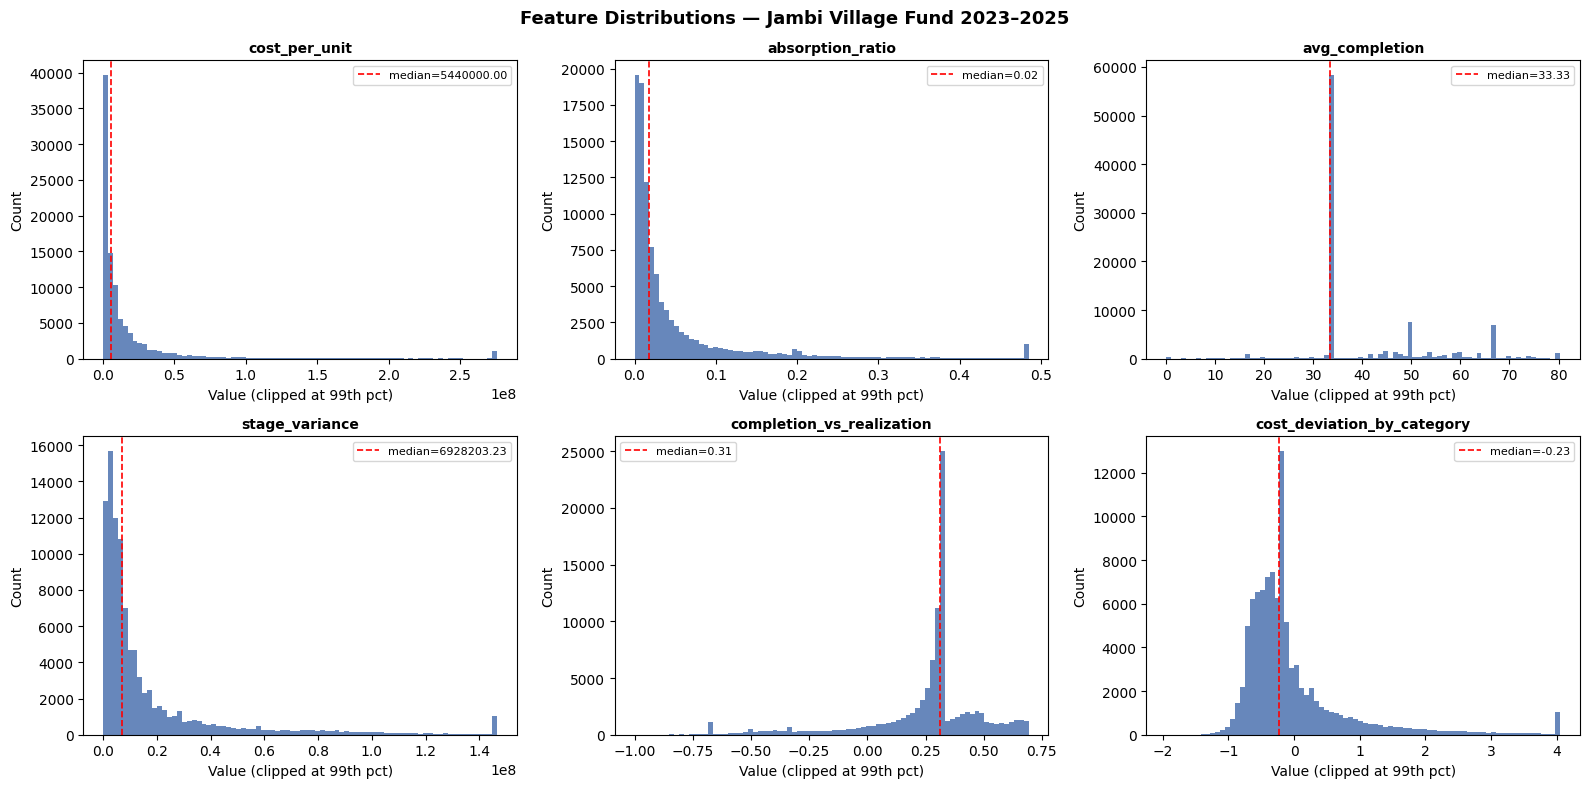

Plot saved.


In [17]:
# ── Cell 18: Feature distribution plots ──────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

PLOT_FEATURES = [
    "cost_per_unit", "absorption_ratio", "avg_completion",
    "stage_variance", "completion_vs_realization", "cost_deviation_by_category"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(PLOT_FEATURES):
    vals = df_model[feat].replace([np.inf, -np.inf], np.nan).dropna()
    # Clip extreme right tail for readability (keep 99th pct)
    p99 = vals.quantile(0.99)
    vals_clipped = vals.clip(upper=p99)
    axes[i].hist(vals_clipped, bins=80, color="#4C72B0", edgecolor="none", alpha=0.85)
    axes[i].set_title(feat, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value (clipped at 99th pct)")
    axes[i].set_ylabel("Count")
    axes[i].axvline(vals.median(), color="red", linestyle="--", linewidth=1.2, label=f"median={vals.median():.2f}")
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions — Jambi Village Fund 2023–2025", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_distributions.png", dpi=150)
plt.show()
print("Plot saved.")

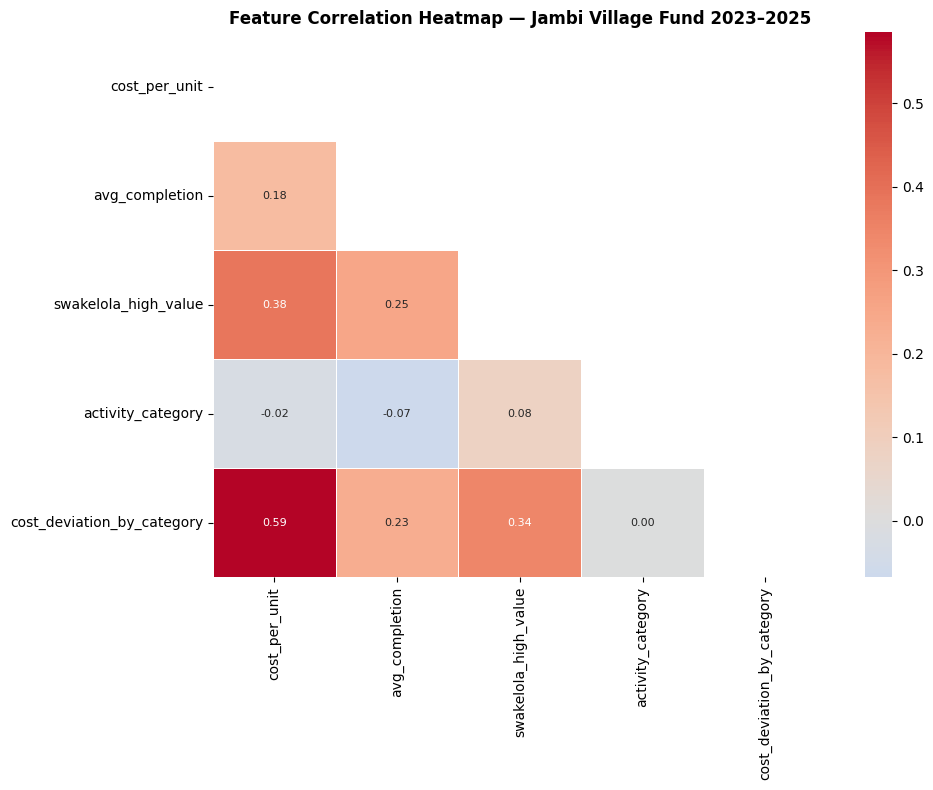

Correlation heatmap saved.


In [18]:
# ── Cell 19: Correlation heatmap (pre-scaling, on FINAL_FEATURES) ─────────
corr = df_model[FINAL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Feature Correlation Heatmap — Jambi Village Fund 2023–2025",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_correlation_heatmap.png", dpi=150)
plt.show()
print("Correlation heatmap saved.")

In [19]:
# ── Cell 20: n_stages_active distribution (zero-inflation diagnostic) ────
vc = df_model["n_stages_active"].value_counts().sort_index()
print("n_stages_active value counts:")
print(vc.to_string())
print(f"\nSingle-stage (n=1) activities: {vc.get(1, 0):,} ({vc.get(1,0)/len(df_model)*100:.1f}%)")
print("Note: These records will show structural high stage_variance — acknowledged limitation.")

n_stages_active value counts:
n_stages_active
1    62757
2    30942
3     5993

Single-stage (n=1) activities: 62,757 (63.0%)
Note: These records will show structural high stage_variance — acknowledged limitation.
